# JSON Error Filtered Analysis

Filter out models with >50% JSON parsing error rate on the simulation branch (`sim_err_msg`),
then generate analysis figures with only reliable models.

In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# Add project root to path for imports
PROJECT_ROOT = Path("../../..").resolve()
sys.path.insert(0, str(PROJECT_ROOT))

from src.exps_performance.logger import create_big_df

plt.style.use("seaborn-v0_8-whitegrid")
sns.set_palette("husl")

RESULTS_DIR = Path("../results")
JSON_ERROR_THRESHOLD = 0.50  # 50% threshold

print(f"Results directory: {RESULTS_DIR.resolve()}")
print(f"JSON Error Threshold: {JSON_ERROR_THRESHOLD * 100:.0f}%")

Results directory: /Users/terrytong/Documents/CCG/ToolProj/src/exps_performance/results
JSON Error Threshold: 50%


## Load Data and Compute Error Rates

In [2]:
def has_real_error(err_msg):
    """Check if err_msg indicates a REAL error.

    Returns True if error, False if 'ok' (no error).
    """
    if not err_msg or err_msg == "":
        return True  # Empty = no response = error
    err_msg = str(err_msg).lower().strip()
    return err_msg not in ["ok", "ok,ok"]


# Load all JSONL results
jsonl_files = sorted(RESULTS_DIR.rglob("*.jsonl"))
print(f"Found {len(jsonl_files)} JSONL files")

df = create_big_df(jsonl_files)
print(f"Loaded {len(df):,} total rows")
print(f"Models found: {df['model'].nunique()}")

Found 28 JSONL files


Loaded 44,850 total rows
Models found: 10


In [3]:
# Compute sim_err per row using sim_err_msg
df["sim_err"] = df["sim_err_msg"].apply(has_real_error)

# Compute per-model error rates
model_err_rates = (
    df.groupby("model")
    .agg(
        {
            "sim_err": "mean",
            "sim_correct": "mean",
            "nl_correct": "mean",
            "code_correct": "mean",
        }
    )
    .reset_index()
)
model_err_rates.columns = ["model", "sim_err_rate", "sim_acc", "nl_acc", "code_acc"]
model_err_rates = model_err_rates.sort_values("sim_err_rate", ascending=False)

print("\nPer-model simulation error rates:")
print(model_err_rates.to_string(index=False))


Per-model simulation error rates:
                             model  sim_err_rate  sim_acc   nl_acc  code_acc
      mistralai/ministral-14b-2512      0.264167 0.150167 0.172333  0.356167
                openai/gpt-4o-mini      0.202833 0.160833 0.206000  0.366667
  qwen/qwen-2.5-coder-32b-instruct      0.183198 0.203292 0.080804  0.078666
meta-llama/llama-3.1-405b-instruct      0.061924 0.226943 0.089592  0.102767
        anthropic/claude-haiku-4.5      0.022500 0.323333 0.389167  0.498333
           google/gemini-2.5-flash      0.001899 0.234810 0.241772  0.455696
  mistralai/mixtral-8x22b-instruct      0.001145 0.197328 0.134351  0.313740
       google/gemini-2.0-flash-001      0.000191 0.223282 0.233397  0.365267
          mistralai/codestral-2508      0.000000 0.222857 0.194762  0.407619
      mistralai/mistral-large-2411      0.000000 0.191358 0.000000  0.175154


## Filter Models by 50% Threshold

In [4]:
# Identify models to KEEP (<=50% error rate)
good_models = model_err_rates[model_err_rates["sim_err_rate"] <= JSON_ERROR_THRESHOLD]["model"].tolist()
bad_models = model_err_rates[model_err_rates["sim_err_rate"] > JSON_ERROR_THRESHOLD]["model"].tolist()

print(f"Models KEPT (<=50% sim error): {len(good_models)}")
for m in good_models:
    rate = model_err_rates[model_err_rates["model"] == m]["sim_err_rate"].iloc[0]
    print(f"  INCLUDED: {m} ({rate * 100:.1f}% error)")

print(f"\nModels FILTERED OUT (>50% sim error): {len(bad_models)}")
for m in bad_models:
    rate = model_err_rates[model_err_rates["model"] == m]["sim_err_rate"].iloc[0]
    print(f"  EXCLUDED: {m} ({rate * 100:.1f}% error)")

# Filter dataframe
df_filtered = df[df["model"].isin(good_models)].copy()
print(f"\nFiltered dataset: {len(df_filtered):,} rows ({len(df_filtered) / len(df) * 100:.1f}% of original)")

Models KEPT (<=50% sim error): 10
  INCLUDED: mistralai/ministral-14b-2512 (26.4% error)
  INCLUDED: openai/gpt-4o-mini (20.3% error)
  INCLUDED: qwen/qwen-2.5-coder-32b-instruct (18.3% error)
  INCLUDED: meta-llama/llama-3.1-405b-instruct (6.2% error)
  INCLUDED: anthropic/claude-haiku-4.5 (2.2% error)
  INCLUDED: google/gemini-2.5-flash (0.2% error)
  INCLUDED: mistralai/mixtral-8x22b-instruct (0.1% error)
  INCLUDED: google/gemini-2.0-flash-001 (0.0% error)
  INCLUDED: mistralai/codestral-2508 (0.0% error)
  INCLUDED: mistralai/mistral-large-2411 (0.0% error)

Models FILTERED OUT (>50% sim error): 0

Filtered dataset: 44,850 rows (100.0% of original)


## Generate Analysis Figure

Generating figure with filtered models...
[plot_v_graph_closed] Filtering to 44 task kinds
[plot_v_graph_closed] Kinds in data: ['activity_selector', 'add', 'articulation_points', 'bellman_ford', 'bfs', 'binary_search', 'bridges', 'bubble_sort', 'dag_shortest_paths', 'dfs', 'dijkstra', 'edp', 'find_maximum_subarray_kadane', 'floyd_warshall', 'gcp', 'graham_scan', 'heapsort', 'ilp_assign', 'ilp_partition', 'ilp_prod', 'insertion_sort', 'jarvis_march', 'kmp_matcher', 'knap', 'ksp', 'lcs', 'lcs_length', 'matrix_chain_order', 'minimum', 'mst_kruskal', 'mst_prim', 'mul', 'naive_string_matcher', 'optimal_bst', 'quickselect', 'quicksort', 'rod', 'segments_intersect', 'spp', 'strongly_connected_components', 'sub', 'task_scheduling', 'topological_sort', 'tsp']


[plot_v_graph_closed] Saved figures/line_closed.png

Figure saved to: /Users/terrytong/Documents/CCG/ToolProj/src/exps_performance/figures/line_closed.png


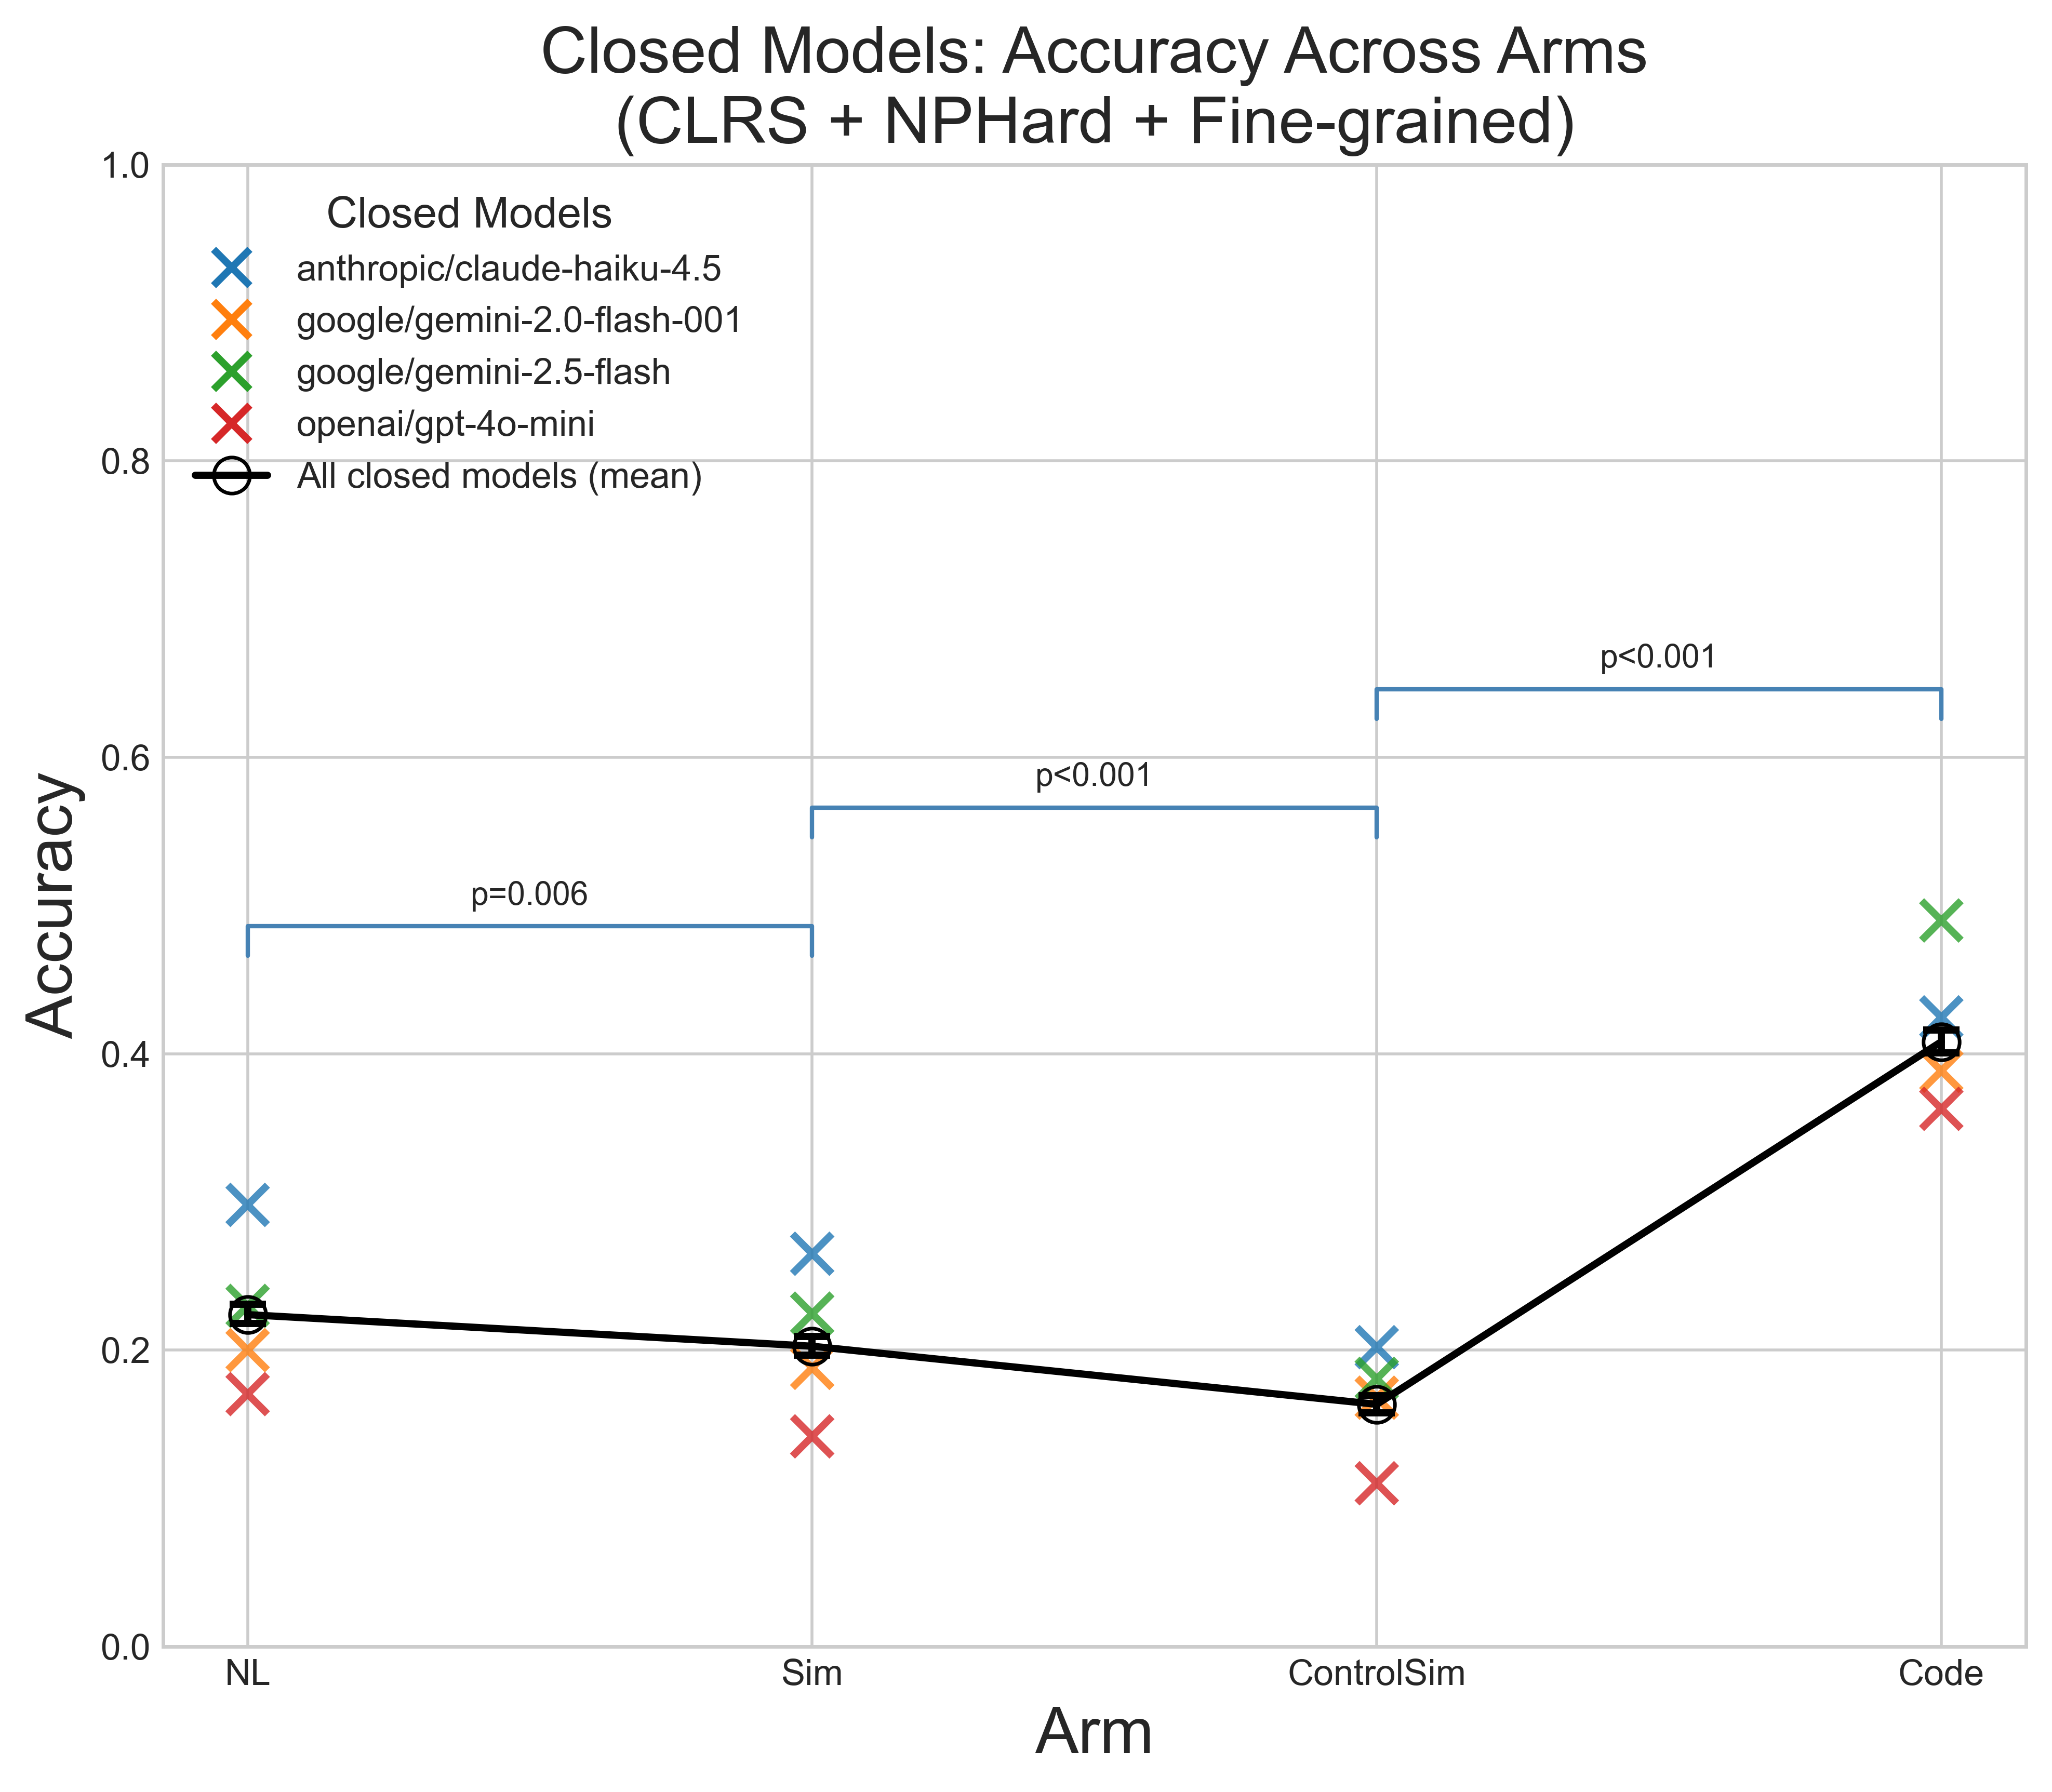

In [5]:
import os

from src.exps_performance.analysis import plot_v_graph_closed

# The analysis.py function saves to 'figures/line_closed.png' relative to cwd
# Change to exps_performance directory so the figure saves in the right place
notebook_dir = Path(".").resolve()
exps_perf_dir = Path("..").resolve()

# Create figures directory if needed
figures_dir = exps_perf_dir / "figures"
figures_dir.mkdir(exist_ok=True)

# Change to exps_performance directory before calling the function
original_cwd = os.getcwd()
os.chdir(exps_perf_dir)

try:
    print("Generating figure with filtered models...")
    plot_v_graph_closed(df_filtered)
    print(f"\nFigure saved to: {figures_dir}/line_closed.png")
finally:
    os.chdir(original_cwd)

## Summary Statistics

In [6]:
# Summary of filtering
print("=" * 60)
print("FILTERING SUMMARY")
print("=" * 60)
print(f"Threshold: {JSON_ERROR_THRESHOLD * 100:.0f}% simulation branch error rate")
print(f"Total models: {len(model_err_rates)}")
print(f"Models kept: {len(good_models)}")
print(f"Models excluded: {len(bad_models)}")
print("")
print(f"Original rows: {len(df):,}")
print(f"Filtered rows: {len(df_filtered):,}")
print(f"Data retained: {len(df_filtered) / len(df) * 100:.1f}%")

FILTERING SUMMARY
Threshold: 50% simulation branch error rate
Total models: 10
Models kept: 10
Models excluded: 0

Original rows: 44,850
Filtered rows: 44,850
Data retained: 100.0%


## Investigation: Why is Accuracy So Low?

The `plot_v_graph_closed` function filters to **CLRS + NPHard + Fine-grained** tasks (hard algorithmic problems), 
excluding gsm8k (easier math word problems). This explains the lower accuracy.

Let's analyze accuracy by task category to verify this hypothesis.

In [7]:
# Define task categories (same as in analysis.py)
CLRS_KINDS = {
    "activity_selector",
    "articulation_points",
    "bellman_ford",
    "bfs",
    "binary_search",
    "bridges",
    "bubble_sort",
    "dag_shortest_paths",
    "dfs",
    "dijkstra",
    "find_maximum_subarray_kadane",
    "floyd_warshall",
    "graham_scan",
    "heapsort",
    "insertion_sort",
    "jarvis_march",
    "kmp_matcher",
    "lcs_length",
    "matrix_chain_order",
    "minimum",
    "mst_kruskal",
    "mst_prim",
    "naive_string_matcher",
    "optimal_bst",
    "quickselect",
    "quicksort",
    "segments_intersect",
    "strongly_connected_components",
    "task_scheduling",
    "topological_sort",
}
NPHARD_KINDS = {"edp", "gcp", "ksp", "spp", "tsp"}
FG_KINDS = {"add", "sub", "mul", "lcs", "rod", "knap", "ilp_assign", "ilp_prod", "ilp_partition"}


def categorize_task(kind):
    if kind == "gsm8k":
        return "GSM8K (easy)"
    if kind in CLRS_KINDS:
        return "CLRS (hard)"
    if kind in NPHARD_KINDS:
        return "NPHard (hard)"
    if kind in FG_KINDS:
        return "Fine-grained (moderate)"
    return "Other"


# Add task category to dataframe
df["task_category"] = df["kind"].apply(categorize_task)

# Show task distribution
print("Task distribution:")
print(df["task_category"].value_counts())
print(f"\nTotal kinds: {df['kind'].nunique()}")
print(f"Unique kinds: {sorted(df['kind'].unique())[:10]}...")

Task distribution:
task_category
CLRS (hard)                15756
Fine-grained (moderate)    13059
NPHard (hard)               6975
Other                       4560
GSM8K (easy)                4500
Name: count, dtype: int64

Total kinds: 49
Unique kinds: ['activity_selector', 'add', 'articulation_points', 'bellman_ford', 'bfs', 'binary_search', 'bridges', 'bsp', 'bubble_sort', 'dag_shortest_paths']...


In [8]:
# Accuracy breakdown by task category and model
print("=" * 80)
print("ACCURACY BY TASK CATEGORY AND MODEL")
print("=" * 80)

breakdown = (
    df.groupby(["model", "task_category"])
    .agg(
        {
            "code_correct": "mean",
            "nl_correct": "mean",
            "sim_correct": "mean",
        }
    )
    .round(3)
)

# Focus on Claude Haiku specifically
print("\nClaude Haiku 4.5 Accuracy by Task Category:")
haiku_data = breakdown.loc["anthropic/claude-haiku-4.5"] if "anthropic/claude-haiku-4.5" in breakdown.index.get_level_values(0) else None
if haiku_data is not None:
    print(haiku_data.to_string())
else:
    print("Claude Haiku not found in data")

print("\nFull breakdown (all models):")
print(breakdown.to_string())

ACCURACY BY TASK CATEGORY AND MODEL

Claude Haiku 4.5 Accuracy by Task Category:
                         code_correct  nl_correct  sim_correct
task_category                                                 
CLRS (hard)                     0.117       0.156        0.144
Fine-grained (moderate)         0.738       0.348        0.335
GSM8K (easy)                    0.939       0.736        0.501
NPHard (hard)                   0.544       0.522        0.408
Other                           0.275       0.525        0.502

Full breakdown (all models):
                                                            code_correct  nl_correct  sim_correct
model                              task_category                                                 
anthropic/claude-haiku-4.5         CLRS (hard)                     0.117       0.156        0.144
                                   Fine-grained (moderate)         0.738       0.348        0.335
                                   GSM8K (easy)         

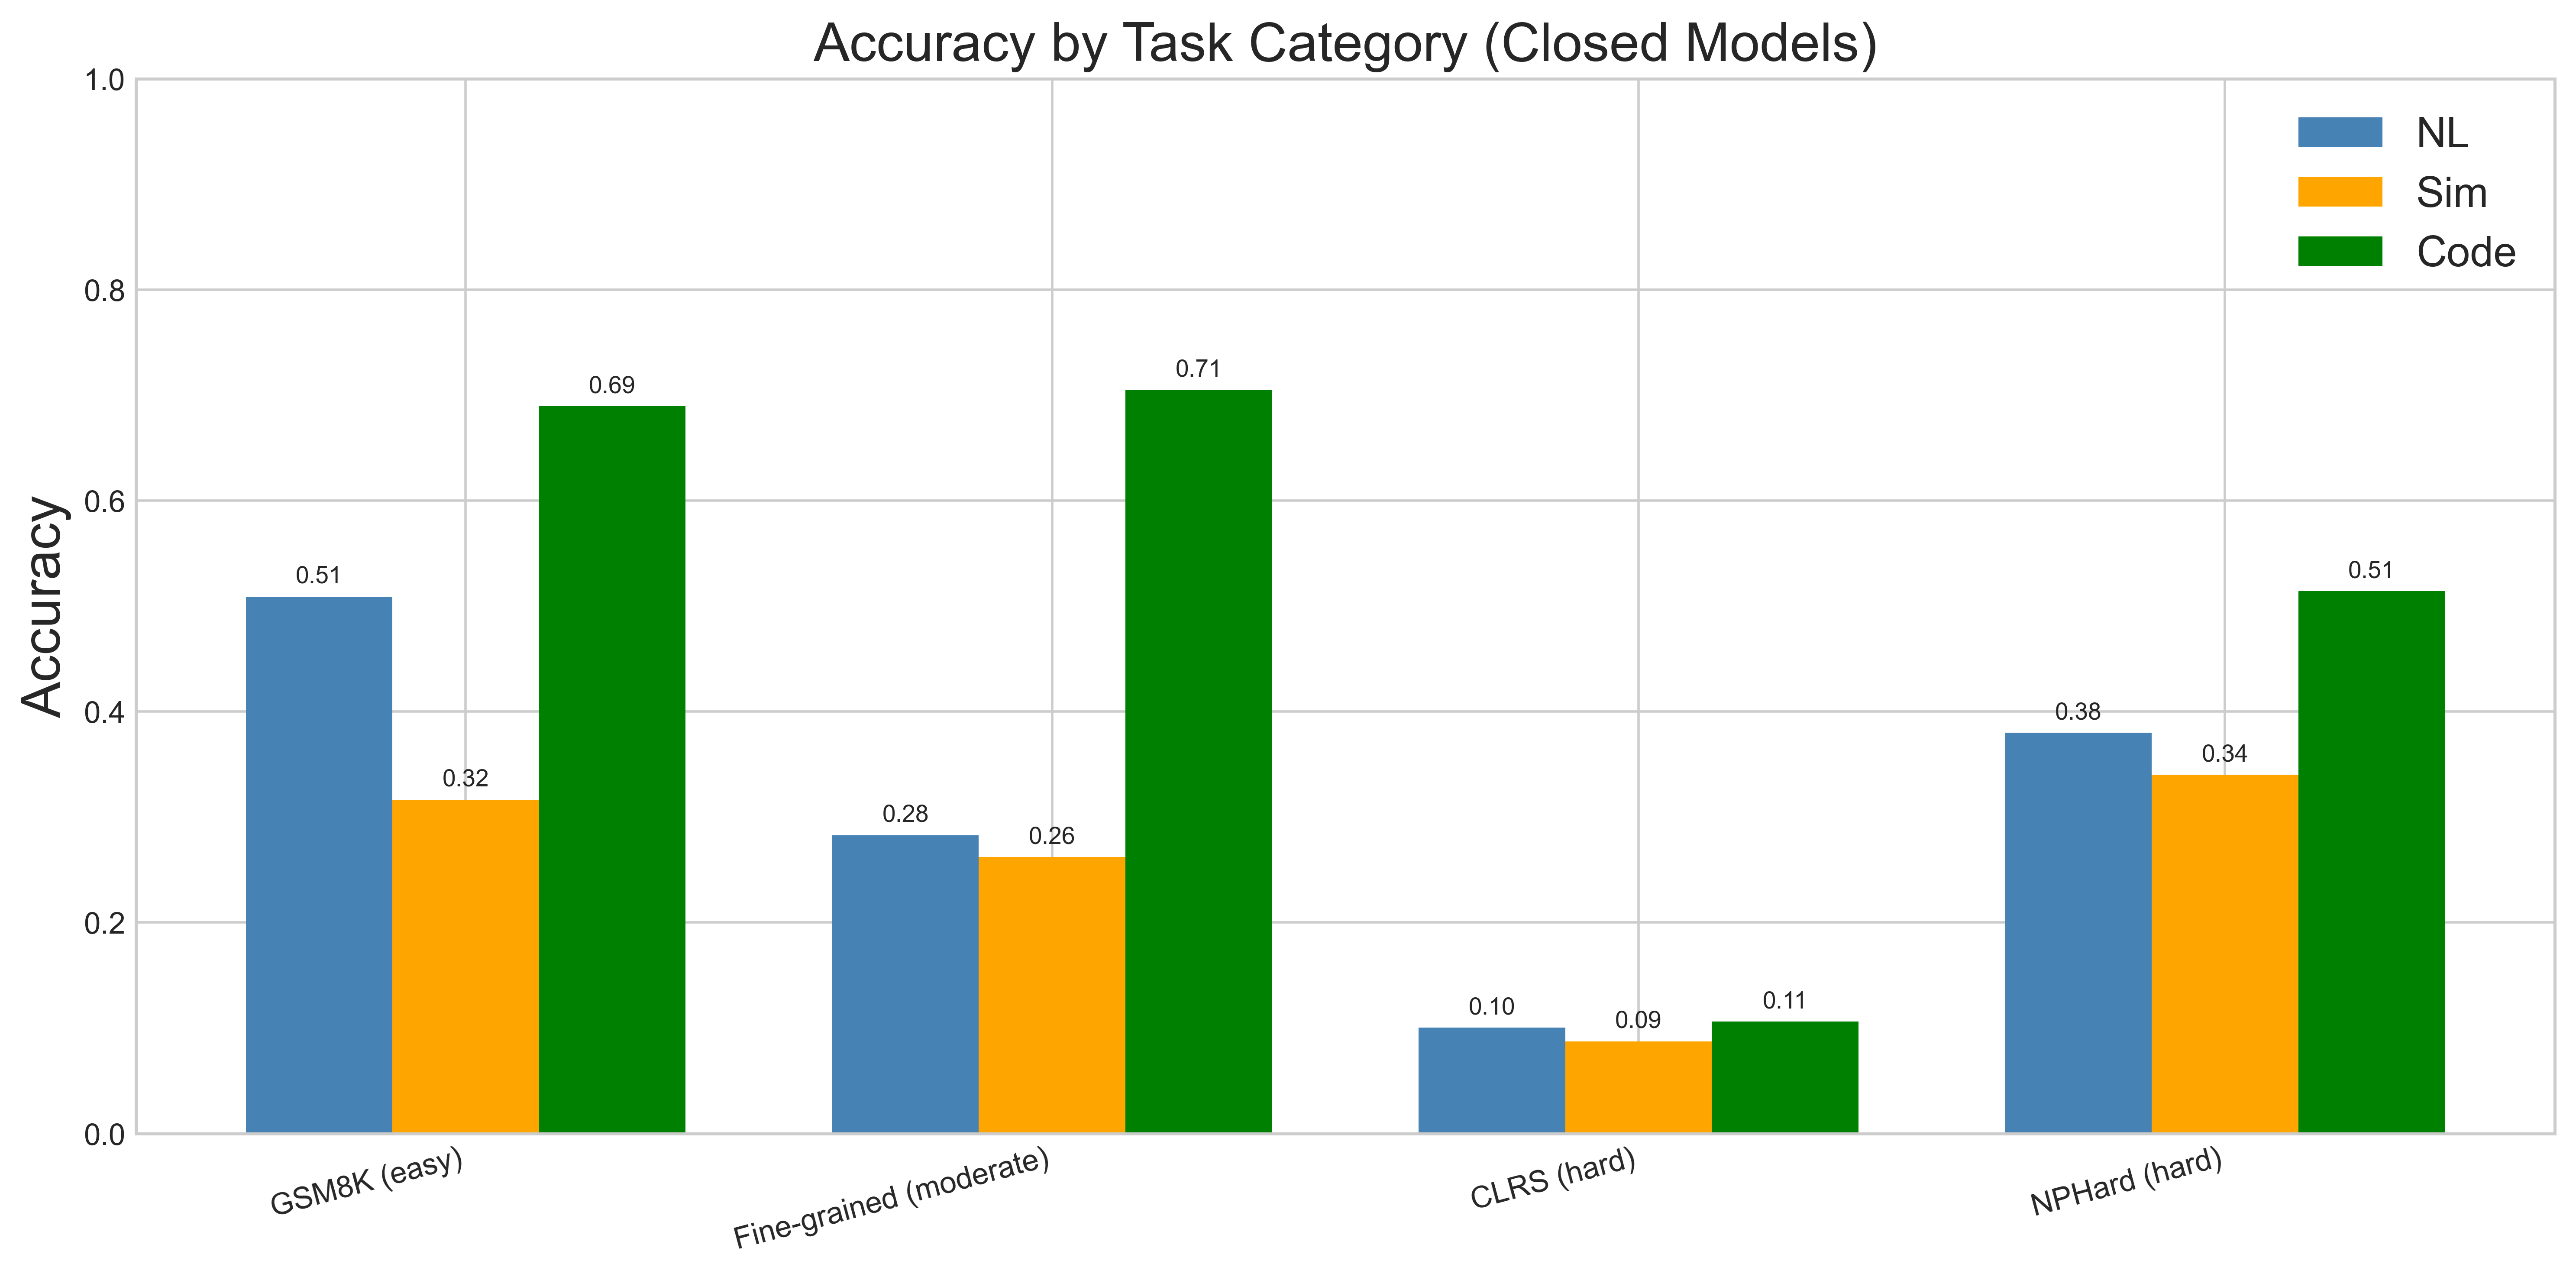


Figure saved to: accuracy_by_task_category.png


In [9]:
# Visualization: Accuracy by task category (closed models only)
closed_providers = {"anthropic", "openai", "google", "xai"}


def is_closed_model(model_name):
    prefix = str(model_name).split("/")[0].lower()
    return prefix in closed_providers


df_closed = df[df["model"].apply(is_closed_model)]

fig, ax = plt.subplots(figsize=(12, 6))

# Compute mean accuracy by category
cat_accuracy = df_closed.groupby("task_category")[["code_correct", "nl_correct", "sim_correct"]].mean()
cat_accuracy = cat_accuracy.reindex(["GSM8K (easy)", "Fine-grained (moderate)", "CLRS (hard)", "NPHard (hard)"])
cat_accuracy = cat_accuracy.dropna()

x = np.arange(len(cat_accuracy))
width = 0.25

bars1 = ax.bar(x - width, cat_accuracy["nl_correct"], width, label="NL", color="steelblue")
bars2 = ax.bar(x, cat_accuracy["sim_correct"], width, label="Sim", color="orange")
bars3 = ax.bar(x + width, cat_accuracy["code_correct"], width, label="Code", color="green")

ax.set_ylabel("Accuracy")
ax.set_title("Accuracy by Task Category (Closed Models)")
ax.set_xticks(x)
ax.set_xticklabels(cat_accuracy.index, rotation=15, ha="right")
ax.legend()
ax.set_ylim(0, 1)

# Add value labels
for bars in [bars1, bars2, bars3]:
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f"{height:.2f}",
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha="center",
            va="bottom",
            fontsize=8,
        )

plt.tight_layout()
plt.savefig("accuracy_by_task_category.png", dpi=150, bbox_inches="tight")
plt.show()

print("\nFigure saved to: accuracy_by_task_category.png")

In [10]:
# Summary: Explain the accuracy difference
print("=" * 80)
print("SUMMARY: Why Accuracy Appears Low")
print("=" * 80)

print("""
The 'low' accuracy in plot_v_graph_closed is EXPECTED because:

1. plot_v_graph_closed uses: CLRS + NPHard + Fine-grained tasks (HARD)
2. Previous analyses used: GSM8K tasks (EASY math word problems)

Task Difficulty Comparison:
""")

# Show average accuracy by category
overall_by_cat = df.groupby("task_category")[["code_correct", "nl_correct"]].mean()
for cat in ["GSM8K (easy)", "Fine-grained (moderate)", "CLRS (hard)", "NPHard (hard)"]:
    if cat in overall_by_cat.index:
        row = overall_by_cat.loc[cat]
        print(f"  {cat:<25}: Code={row['code_correct'] * 100:.1f}%, NL={row['nl_correct'] * 100:.1f}%")

print("""
CONCLUSION: The accuracy IS lower on algorithmic tasks because they are 
genuinely harder than GSM8K math problems. This is expected behavior, not a bug.
""")

SUMMARY: Why Accuracy Appears Low

The 'low' accuracy in plot_v_graph_closed is EXPECTED because:

1. plot_v_graph_closed uses: CLRS + NPHard + Fine-grained tasks (HARD)
2. Previous analyses used: GSM8K tasks (EASY math word problems)

Task Difficulty Comparison:

  GSM8K (easy)             : Code=41.0%, NL=27.9%
  Fine-grained (moderate)  : Code=62.1%, NL=21.5%
  CLRS (hard)              : Code=8.1%, NL=6.8%
  NPHard (hard)            : Code=39.9%, NL=28.8%

CONCLUSION: The accuracy IS lower on algorithmic tasks because they are 
genuinely harder than GSM8K math problems. This is expected behavior, not a bug.

